# Partial Replication of Anthropic's Emotion Vectors with *Gemma 4 E2B* and *GPT 2 Medium* inside Google Colab T4 Notebook

Abraham Jhared Flores Azcona

abrahamjhared.flores@gmail.com

April 25, 2026


## Environment Dependencies
**[IMPORTANT]** `transformers==5.5.0` is required to access Gemma 4 E2B from HuggingFace.

**[IMPORTANT]** `kaleido==0.2.1` is required to download plots generated from this Colab AND to remove confusing *"package not found"* error when using recent version.

In [ ]:
# Core Machine Learning & TPU Support
%pip install torch torch_xla[tpu] -f https://storage.googleapis.com/tpu-pytorch/wheels/tpuvm/torch_xla-2.1-cp310-cp310-linux_x86_64.whl
%pip install transformers==5.5.0 accelerate

# Interpretability & Visualization
%pip install plotly pandas scikit-learn huggingface-hub
%pip install -U kaleido==0.2.1

Looking in links: https://storage.googleapis.com/tpu-pytorch/wheels/tpuvm/torch_xla-2.1-cp310-cp310-linux_x86_64.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.8/149.8 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 123.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.8 MB/s eta 0:00:00


## Python snippets

### [1] Load relevant pip packages & global variables

**Description of global variables**

*   `kOutDir` path for output directory of the Colab (in this case, `./research_data`).
*   `gAccelerator` type of hardware accelerator used in the Colab.
*   `gDevice` type of hardware component; CPU or GPU.
*   `gTokenizer` instance of LLM tokenizer.
*   `gTargetLayer` number of the desired layer where "emotion" vector semantics arise.
*   `gStoryFile` path to `emotion_stories`.
*   `gEmotionLibrary` dictionary containing the name of the emotion (i.e: happy, calm, etc.), and the vector representation stored as *bfloat16*.
*   `gNeutralVectors` list containing the neutral vectors stored as *bfloat16*.

In [ ]:
import time
import json
import os
import gc
import zipfile
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from typing import List, Dict
from transformers import AutoModelForCausalLM, AutoTokenizer
from accelerate import Accelerator
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from google.colab import files


# Global variables for the Collab refactor
kOutDir = "./research_data"
gAccelerator = None
gDevice = None
gTokenizer = None
gModel = None
gTargetLayer = None # Layer 24 has consistent emotion classifications
gStoryFile = None
gEmotionLibrary: Dict[str, torch.Tensor] = None
gNeutralVectors: List[torch.Tensor] = None

### [2] Load desired model

**Description of global variables**

* `kModelIdx` HuggingFace's ID for desired LLM model hosted in their platform.

In [ ]:
kModelIdx = "openai-community/gpt2-medium"

In [ ]:
kModelIdx = "google/gemma-4-E2B"

### [3] Load relevant "emotion" vector data

**Description of global variables**

* `neutralPrompts` list of 50 entries depicting *neutral* prompts, which consist of statements and orders.
* `emotionLabels` list of desired emotions for vector extraction.
* `storyTopics` list of ten topics for emotion story generation.


In [ ]:
# @title
# Neutral prompt list from rain1955/emotion-vector-replication extendend with Google Gemini 3 Fast (04/09/2026)
neutralPrompts = [
  # prompts originating from rain1955/emotion-vector-replication
  "The meeting is scheduled for 3pm tomorrow.",
  "Please find the attached document.",
  "The temperature today is 22 degrees Celsius.",
  "The project deadline has been moved to next Friday.",
  "The store is located on the corner of Main Street.",
  "Chapter 3 discusses the economic implications.",
  "The software update includes several bug fixes.",
  "The report contains data from the past quarter.",
  "The committee will review the proposal next week.",
  "The library opens at 9am on weekdays.",
  # prompts generated with Google Gemini 3 Fast (04/09/2026)
  "The itinerary for the conference has been finalized.",
  "Data collection will commence at the beginning of the month.",
  "The user manual provides instructions for hardware setup.",
  "Standard procedure requires a signed authorization form.",
  "The server maintenance is performed every Sunday night.",
  "Historical records are stored in the basement archive.",
  "The chemical reaction occurs at room temperature.",
  "Please submit your expenses by the end of the day.",
  "The laboratory results will be available in 48 hours.",
  "The publication follows a strict peer-review process.",
  "The office is situated on the fourth floor of the building.",
  "Annual inspections are mandatory for all equipment.",
  "The software license expires at the end of the calendar year.",
  "The lecture series covers fundamental principles of physics.",
  "The supply chain manager coordinates all logistics.",
  "The router configuration remains unchanged since the last update.",
  "Participant feedback is collected through an anonymous survey.",
  "The contract specifies the terms and conditions of employment.",
  "Geological surveys indicate a high concentration of minerals.",
  "The system generates a log file for every transaction.",
  "Traffic flow is monitored by automated sensors.",
  "The workshop focuses on improving technical documentation.",
  "The final audit confirmed the accuracy of the financial statements.",
  "The museum is closed for renovations until next month.",
  "Utility bills are calculated based on monthly consumption.",
  "The inventory count is updated every Tuesday morning.",
  "The parking garage remains open 24 hours a day.",
  "The application process requires a valid form of identification.",
  "The thermostat is set to maintain a constant temperature.",
  "The user interface supports three different language options.",
  "The flight departure is confirmed for gate 12B.",
  "The building specifications meet the current safety codes.",
  "The printer requires a replacement toner cartridge.",
  "The database backup was completed successfully at midnight.",
  "The street lights are programmed to activate at sunset.",
  "The employee handbook outlines the company's privacy policy.",
  "The water filtration system is inspected twice a year.",
  "The package dimensions must not exceed the standard limit.",
  "The conference call will be recorded for future reference.",
  "The technical support team is available via email."
]

In [ ]:
# @title
# Emotion word list from rain1955/emotion-vector-replication
emotionLabels = [
    'calm', 'loving', 'sad', 'guilty', 'desperate', 'afraid', 'angry', 'surprised', 'happy'
]

# Topics from rain1955/emotion-vector-replication
storyTopics = [
    "a student preparing for an exam",
    "a chef cooking a meal for guests",
    "a parent watching their child play",
    "a soldier returning home",
    "an artist finishing a painting",
    "a driver stuck in traffic",
    "a doctor delivering news to a patient",
    "a traveler arriving in a new city",
    "a musician performing on stage",
    "a shopkeeper closing for the day",
]

If you wish, you can load the 20-emotions variant of `emotionLabels`. Plots and Emotion Vector Generation will vary.

In [ ]:
# Emotion word list from rain1955/emotion-vector-replication
emotionLabels = [
  "happy", "sad", "angry", "afraid", "calm",
  "desperate", "loving", "guilty", "surprised", "nervous",
  "proud", "inspired", "spiteful", "brooding", "playful",
  "anxious", "confused", "disgusted", "lonely", "hopeful"
]

### [4] Load relevant helper functions

#### `initialize()`

* Initializes previously-described global variables of the Colab environment.

#### `freeVRAM()`

* If using an NVIDIA GPU, clears and frees cached VRAM. Useful to minimize VRAM footprint, which spikes during emotion vector usage.

#### `normalizeVector()`

* *@input:* `vector` a PyTorch vector.
* Helper function wrapper to normalize a vector to unit length.

#### `computeCosineSimilarity()`

* *@input:* `vectorA` a PyTorch vector.
* *@input:* `vectorB` a PyTorch vector.
* Helper function wrapper to calculate cosine similarity.

In [ ]:
def initialize():
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    print(f"[INIT] Initializing Research Orchestrator for {kModelIdx}...")
    gAccelerator = Accelerator()
    gDevice = gAccelerator.device
    gTokenizer = AutoTokenizer.from_pretrained(kModelIdx)
    gTokenizer.padding_side = "right" # gpt 2 setting
    if gTokenizer.pad_token is None:
        gTokenizer.pad_token = gTokenizer.eos_token
    gModel = AutoModelForCausalLM.from_pretrained(
        kModelIdx,
        torch_dtype=torch.bfloat16
    ).to(gDevice)
    gModel.eval()
    gEmotionLibrary = {}
    gNeutralVectors = []
    gStoryFile = os.path.join(kOutDir, "emotion_stories.json")
    print(f"[INIT] Model loaded. Target Layer: {gTargetLayer} | Device: {gDevice}")

def freeVRAM():
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gAccelerator.free_memory()

def normalizeVector(vector):
    vector = vector.view(-1)  # force 1D
    return vector / (vector.norm() + 1e-9)

def computeCosineSimilarity(vectorA, vectorB):
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    return F.cosine_similarity(vectorA.unsqueeze(0), vectorB.unsqueeze(0)).item()

#### `getExistingKeys()`

* Helper function wrapper unique JSON (emotion, topic, sample) tuples on disk.

In [ ]:
def getExistingKeys() -> set:
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    """Checkpointing: Identifies unique (emotion, topic, sample) tuples on disk."""
    existingKeys = set()
    if os.path.exists(gStoryFile):
        with open(gStoryFile, "r", encoding="utf-8") as fileHandle:
            for line in fileHandle:
                try:
                    entryData = json.loads(line)
                    existingKeys.add(f"{entryData['emotion']}_{entryData['topic_idx']}_{entryData['story_idx']}")
                except: continue
    return existingKeys

#### `generateVignettes()`

* *@input:* `promptInput` text prompt to generate a story from.
* *@input:* `nSamples` number of samples to generate. *Sets to 1 by default.*
* Helper function wrapper to normalize a vector to unit length.

In [ ]:
def generateVignettes(promptInput: str, nSamples: int = 1, category: str = "Unset") -> List[str]:
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    gTokenizer.padding_side = "left"
    tokenizedInputs = gTokenizer(promptInput, padding=True, return_tensors="pt").to(gDevice)
    inputLength = tokenizedInputs['input_ids'].shape[1]
    vignetteList = []
    for _ in range(nSamples):
        outputTokens = gModel.generate(
            **tokenizedInputs, max_new_tokens=150, temperature=0.85, do_sample=True,
            pad_token_id=gTokenizer.pad_token_id, eos_token_id=gTokenizer.eos_token_id
        )
        vignetteList.append(gTokenizer.decode(outputTokens[0][inputLength:], skip_special_tokens=True).strip())
    return vignetteList

#### `generateStructuredStories()`

* *@input:* `emotions` list of emotions to generate expected stories from.
* *@input:* `topics` list of topics to based our story content from.
* *@input:* `samplesPerPair` number of samples to generate from (emotion, topic).
* Generates desired stories with the list of emotions and topics, and stores them into disk with a JSON file.

In [ ]:
def generateStructuredStories(emotions: List[str], topics: List[str], samplesPerPair: int = 5):
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    """Generates the grounded vignette dataset for vector extraction."""
    existingKeys = getExistingKeys()
    with open(gStoryFile, "a", encoding="utf-8") as fileHandle:
        for emotionIndex, emotionLabel in enumerate(emotions):
            for topicIndex, topicText in enumerate(topics):
                for sampleIndex in range(samplesPerPair):
                    uniqueKey = f"{emotionLabel}_{topicIndex}_{sampleIndex}"
                    if uniqueKey in existingKeys: continue

                    promptContent = f"Write a short paragraph about {topicText}. The character is feeling {emotionLabel}. Output only the paragraph."
                    chatMessages = [{"role": "user", "content": promptContent}]
                    formattedPrompt = gTokenizer.apply_chat_template(chatMessages, tokenize=False, add_generation_prompt=True)

                    generatedStory = generateVignettes(formattedPrompt, nSamples=1, category=f"{emotionLabel}/{topicText[:10]}")[0]
                    storyRecord = {
                        "emotion": emotionLabel, "topic_idx": topicIndex, "topic": topicText,
                        "story_idx": sampleIndex, "text": generatedStory, "timestamp": time.time()
                    }
                    fileHandle.write(json.dumps(storyRecord, ensure_ascii=False) + "\n")
                    fileHandle.flush()
                    existingKeys.add(uniqueKey)
            freeVRAM()

#### `getHiddenRepresentation()`

* *@input:* `promptList` list of text prompts to be used for hidden rerpesentation (activation) extraction.
* *@input:* `layerIndex` number representing the layer where activation extraction must happen.
* *@input:* `lastNTokens` number of last tokens where we'll extract activation from.
* Obtains the hidden state representation of the text prompt at a given layer.

#### `getBatchActivations()`

* *@input:* `textList` list of text prompts to be used for hidden representation (activation) extraction.
* *@input:* `layerIndex` number representing the layer where activation extraction must happen.
* Function wrapper of `getHiddenRepresentation()`.

In [ ]:
def getHiddenRepresentation(promptList: List[str], layerIndex: int, lastNTokens: int = 10) -> torch.Tensor:
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile

    gTokenizer.padding_side = "right" # gpt 2 setting
    tokenizedBatch = gTokenizer(promptList, return_tensors="pt", truncation=True, padding=True).to(gDevice)

    with torch.no_grad():
        outputs = gModel(**tokenizedBatch, output_hidden_states=True)

    hiddenStates = outputs.hidden_states[layerIndex]  # [B, T, D]
    attentionMask = tokenizedBatch["attention_mask"]  # [B, T]

    batchVectors = []
    for i in range(hiddenStates.shape[0]):
        seqLen = int(attentionMask[i].sum().item())
        if seqLen > 50:
            startIdx = 50
        else:
            startIdx = seqLen // 2  # fallback for short samples
        vector = hiddenStates[i, startIdx:seqLen, :].mean(dim=0)
        batchVectors.append(vector)

    return torch.stack(batchVectors)

def captureBatchActivations(textList: List[str], layerIndex: int) -> torch.Tensor:
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    return getHiddenRepresentation(textList, layerIndex)

#### `extractEmotionVector()`

* *@input:* `emotionLabel` name of the desired emotion to extract its vector representation.
* *@input:* `neutralTexts` list of statements and orders used as noise.
* Extracts the emotion stories from a JSON file, captures the hidden activations representative of the stories, and saves the vectors into our runtime emotion library.

In [ ]:
# Redefine extractEmotionVector with batching and JSONL parsing fix
def extractEmotionVector(emotionLabel: str, neutralTexts: List[str]):
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile

    print(f"[EXTRACT] Emotion: {emotionLabel.upper()} | Layer: {gTargetLayer}")

    emotionalTexts = []

    # Correct variable name: emotion -> emotionLabel
    filePath = os.path.join(kOutDir, f"emotion_stories/{emotionLabel}_stories.json")
    if os.path.exists(filePath):
        print(f"[EXTRACT] {filePath} does exist!")
        with open(filePath, "r") as f:
            print(f"[EXTRACT] Opened the JSON file!")
            # Correct JSON loading for JSONL format
            dataList = json.load(f) # Note: json.load(), not loads()
            print(type(dataList))
            print(dataList[:1] if isinstance(dataList, list) else dataList)
            for d in dataList:
                print(f"[EXTRACT] Inside the JSON parsing!")
                emotionalTexts.append(d['text'])

    if not emotionalTexts:
        print(f"[WARN] No emotional texts found for {emotionLabel}. Skipping.")
        return None

    # Introduce batching for processing emotionalTexts before calling captureBatchActivations
    batchSize = 8 # Adjusted batch size for GPU memory. This can be tuned.
    allActivations = []

    for i in range(0, len(emotionalTexts), batchSize):
        batchEmotionalTexts = emotionalTexts[i:i + batchSize]
        if batchEmotionalTexts: # Ensure batch is not empty
            activationsBatch = captureBatchActivations(batchEmotionalTexts, gTargetLayer)
            allActivations.append(activationsBatch)
            # It's good practice to free memory explicitly when dealing with OOM
            del activationsBatch
            torch.cuda.empty_cache()

    if not allActivations:
        print(f"[WARN] No activations were generated for {emotionLabel}. Skipping.")
        return None

    # Concatenate all batched activations
    activationsVector = torch.cat(allActivations, dim=0)

    # Store RAW mean (baseline subtraction later)
    rawMeanVector = activationsVector.mean(dim=0).float()
    gEmotionLibrary[emotionLabel] = rawMeanVector

    return None

#### `normalizeEmotionVectors()`


* Normalizes emotion vectors and neutral vectors, and updates emotion vectors by subtracting the global mean of the emotions and the neutral.

In [ ]:
def normalizeEmotionVectors():
    global gEmotionLibrary, gNeutralVectors, gDevice

    if gNeutralVectors is None or len(gNeutralVectors) == 0:
        raise ValueError("Neutral vectors must be computed before finalization.")

    # --- STEP 1: Neutral baseline ---
    neutralMean = gNeutralVectors.mean(dim=0)

    for emotionKey in gEmotionLibrary:
        gEmotionLibrary[emotionKey] = gEmotionLibrary[emotionKey] - neutralMean

    # --- STEP 2: Global emotion centering (CRITICAL) ---
    stacked = torch.stack(list(gEmotionLibrary.values()))
    globalMean = stacked.mean(dim=0)

    for emotionKey in gEmotionLibrary:
        gEmotionLibrary[emotionKey] = gEmotionLibrary[emotionKey] - globalMean

    # --- STEP 3: Normalize ONLY ONCE at the end ---
    for emotionKey in gEmotionLibrary:
        vector = gEmotionLibrary[emotionKey]
        vector = vector / (vector.norm() + 1e-9)
        gEmotionLibrary[emotionKey] = vector.to(torch.bfloat16).to(gDevice)

    print("[FINALIZE] Emotion vectors centered + normalized.")

#### `extractNeutralVectors()`


* Special wrapper of `extractEmotionVectors()` for neutral prompts.

In [ ]:
def extractNeutralVectors(neutralTexts: List[str]):
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    print(f"[EXTRACT] Neutral | Layer: {gTargetLayer}")
    gNeutralVectors = captureBatchActivations(neutralTexts, gTargetLayer)

#### `getTopEmotionLogits()`

* *@input:* `emotionLabel` name of the desired emotion to print its top logit tokens
* *@input:* `topK` number of clusters to extract logits from. *Defaults to 10*.
* Prints the most relevant tokens related to an emotion vector. We standardize the logit lens to extract them from a Bell Curve distribution.

#### `getBottomEmotionLogits()`

* *@input:* `emotionLabel` name of the desired emotion to print its top logit tokens
* *@input:* `bottomK` number of clusters to extract logits from. *Defaults to 10*.
* Prints the most relevant tokens related to an emotion vector. We standardize the logit lens to extract them from a Bell Curve distribution.

In [ ]:
# @title
def getTopEmotionLogits(emotionLabel: str, topK: int = 5):
    global gModel, gTokenizer, gEmotionLibrary

    emotionVector = gEmotionLibrary[emotionLabel].to(gModel.device).to(gModel.dtype)

    with torch.no_grad():
        if hasattr(gModel, "model"):
            if hasattr(gModel.model, "norm"):
                emotionVector = gModel.model.norm(emotionVector)
            elif hasattr(gModel.model, "final_layernorm"):
                emotionVector = gModel.model.final_layernorm(emotionVector)
        elif hasattr(gModel, "transformer") and hasattr(gModel.transformer, "ln_f"):
            emotionVector = gModel.transformer.ln_f(emotionVector)

        logits = gModel.lm_head(emotionVector.unsqueeze(0)).squeeze(0)

        logitMean = logits.mean()
        logitStdDev = logits.std()
        zScores = (logits - logitMean) / logitStdDev

    topValues, topIndices = torch.topk(zScores, topK)

    results = []

    for i in range(topK):
        tokenId = topIndices[i].item()
        tokenStr = gTokenizer.decode([tokenId])  # DO NOT strip

        results.append({
            "token": tokenStr,       # raw token (keep spaces!)
            "tokenId": tokenId,      # ground truth
            "zScore": topValues[i].item()
        })

    return results

# @title
def getBottomEmotionLogits(emotionLabel: str, bottomK: int = 5):
    global gModel, gTokenizer, gEmotionLibrary

    emotionVector = gEmotionLibrary[emotionLabel].to(gModel.device).to(gModel.dtype)

    with torch.no_grad():
        if hasattr(gModel, "model"):
            if hasattr(gModel.model, "norm"):
                emotionVector = gModel.model.norm(emotionVector)
            elif hasattr(gModel.model, "final_layernorm"):
                emotionVector = gModel.model.final_layernorm(emotionVector)
        elif hasattr(gModel, "transformer") and hasattr(gModel.transformer, "ln_f"):
            emotionVector = gModel.transformer.ln_f(emotionVector)

        logits = gModel.lm_head(emotionVector.unsqueeze(0)).squeeze(0)

        logitMean = logits.mean()
        logitStdDev = logits.std()
        zScores = (logits - logitMean) / logitStdDev

    topValues, topIndices = torch.topk(zScores, bottomK, largest=False)

    results = []

    for i in range(bottomK):
        tokenId = topIndices[i].item()
        tokenStr = gTokenizer.decode([tokenId])  # DO NOT strip

        results.append({
            "token": tokenStr,       # raw token (keep spaces!)
            "tokenId": tokenId,      # ground truth
            "zScore": topValues[i].item()
        })

    return results

#### `printEmotionLogitsFormatted()`

* *@input:* `emotionLabel` name of the desired emotion to print its top logit tokens
* *@input:* `topK` number of clusters to extract logits from. *Defaults to 5*.
* Prints the most relevant tokens related to an emotion vector. We standardize the logit lens to extract them from a Bell Curve distribution.

In [ ]:
def printEmotionLogitsFormatted(emotionLabel: str, topK: int = 5):
    resultsTop = getTopEmotionLogits(emotionLabel, topK)
    resultsBottom = getBottomEmotionLogits(emotionLabel, topK)

    print(f"\n[LOGIT LENS] Semantic Strength for '{emotionLabel.upper()}':")
    print(f"\n[LOGIT LENS] TOP {topK} Tokens:")
    for i, entry in enumerate(resultsTop):
        token = entry["token"]          # keep raw token
        sigmaScore = entry["zScore"]

        # IMPORTANT: strip only for display, not for computation
        print(f"{i+1}. {token.strip():<15} (+{sigmaScore:.2f}σ)")

    print(f"\n[LOGIT LENS] BOTTOM {topK} Tokens:")
    for i, entry in enumerate(resultsTop):
        token = entry["token"]          # keep raw token
        sigmaScore = entry["zScore"]

        # IMPORTANT: strip only for display, not for computation
        print(f"{i+1}. {token.strip():<15} (+{sigmaScore:.2f}σ)")

#### `getLayerModule()`

* *@input:* `model` name of the desired emotion to print its top logit tokens
* *@input:* `target_idx` number of the desired target layer.
* Obtains the vector layer representation expected of Gemma 4 and GPT 2 models.

In [ ]:
# --- PHASE 1: DYNAMIC LAYER IDENTIFICATION ---
def getLayerModule(model, target_idx):
    # Path A: Standard Gemma/Llama nesting
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers[target_idx]

    # Path B: Gemma 4 E2B conditional generation wrapper
    if hasattr(model, "language_model"):
        return getLayerModule(model.language_model, target_idx)

    # Path C: Brute-force search for the primary ModuleList
    # This is the most robust fallback for non-standard E2B implementations
    for _, module in model.named_modules():
        if isinstance(module, torch.nn.ModuleList) and len(module) > target_idx:
            return module[target_idx]

    return None

#### `performSingularEmotionProbeSteering()`

* *@input:* `emotionVector` PyTorch vector of the desired emotion.
* *@input:* `inputPrompt` text prompt that must be provided to the model.
* *@input:* `steeringValue` scalar value for steering strength.
* Generates a text prompt altered by a singular emotion vector scaled by steering strength.

In [ ]:
def performSingularEmotionProbeSteering(emotionVector, inputPrompt, steeringValue):
    global gModel, gTokenizer, gTargetLayer, gDevice

    # Ensure vector is on the right device and dtype
    # Gemma 4 often uses bfloat16; match the model's dtype
    emotionVector = emotionVector.to(gDevice).to(gModel.dtype)

    def steeringHook(module, input, output):
        # Handle the standard (hidden_states, optional_tuple) output
        if isinstance(output, tuple):
            hiddenStates = output[0]
        else:
            hiddenStates = output

        # Scale relative to the current activation magnitude (standardized steering)
        # We use a small epsilon to avoid division by zero
        scale = hiddenStates.norm(dim=-1, keepdim=True)

        # Expand vector to match sequence
        expandedVector = emotionVector.view(1, 1, -1)

        # Prepare the steering delta
        # Shape must be [Batch, SeqLen, HiddenDim]
        steeringDelta = (steeringValue * scale * emotionVector)

        # Apply steering to EVERY token in the current pass
        # During 'generate', after the first token, seq_len is usually 1,
        # so this naturally targets the "current" token being predicted.
        steeredStates = hiddenStates + steeringDelta

        if isinstance(output, tuple):
            return (steeredStates,) + output[1:]
        return steeredStates

    # ROBUST ARCHITECTURE CHECK (Supports GPT2 and Gemma 4)
    targetLayer = getLayerModule(gModel, gTargetLayer)
    hookHandle = targetLayer.register_forward_hook(steeringHook)

    try:
        inputTokens = gTokenizer(inputPrompt, return_tensors="pt", truncation=True, padding=True).to(gDevice)

        # Use a slightly lower temperature for Gemma 4 to see the steering effect clearly
        with torch.no_grad():
            outputTokens = gModel.generate(
                **inputTokens,
                max_new_tokens=100,
                temperature=0.7,
                do_sample=True,
                pad_token_id=gTokenizer.eos_token_id # Gemma often uses EOS as PAD
            )
    finally:
        hookHandle.remove()

    outputText = gTokenizer.decode(outputTokens[0], skip_special_tokens=True)
    #print(f"\n[STEERING] Value: {steeringValue} | Prompt: {inputPrompt[:50]}...")
    #print(f"Output:\n{outputText}")
    return outputText

#### `superviseSingularEmotionProbeActivation()`

* *@input:* `emotionVector` PyTorch vector of the desired emotion.
* *@input:* `inputPrompt` text prompt that must be provided to the model.
* Computes the cosine similarity score of the emotion vector and the provided text prompt.

In [ ]:
def superviseSingularEmotionProbeActivation(emotionVector, inputPrompt, lastNTokens = 10):
    """
    Identifies the model's internal layers dynamically and supervises
    the alignment between latent activations and target emotion vectors.
    """
    global gModel, gTokenizer, gTargetLayer, gDevice

    activationBuffer = []

    def observationHook(module, input, output):
        # Handle the Gemma 4 (hidden_states, cache) tuple output
        hiddenStates = output[0] if isinstance(output, tuple) else output
        # Move to CPU immediately to prevent GPU memory saturation
        activationBuffer.append(hiddenStates.detach().cpu())
        return output

    vectorLayer = getLayerModule(gModel, gTargetLayer)

    if vectorLayer is None:
        raise ValueError(f"CRITICAL: Failed to locate Layer {gTargetLayer}. "
                         f"Check model structure: {type(gModel)}")

    # --- PHASE 2: HOOK REGISTRATION & INFERENCE ---
    hookHandle = vectorLayer.register_forward_hook(observationHook)

    try:
        inputs = gTokenizer(inputPrompt, return_tensors="pt", padding=True, truncation=True).to(gDevice)

        with torch.no_grad():
            _ = gModel(**inputs)

        rawTensor = activationBuffer[0]        # [B, T, D]
        hiddenStates = rawTensor[0]            # [T, D]

        attentionMask = inputs["attention_mask"][0]
        seqLen = int(attentionMask.sum().item())

        N = min(lastNTokens, seqLen)
        startIdx = max(0, seqLen - N)

        validHidden = hiddenStates[:seqLen]
        pooledVector = hiddenStates[startIdx:seqLen].mean(dim=0)

        # Ensure pooledVector is on the correct device (gDevice) before normalization and similarity
        pooledVector = pooledVector.to(gDevice)

        pooledVector = normalizeVector(pooledVector)
        targetVector = normalizeVector(emotionVector)

        similarity = computeCosineSimilarity(pooledVector, targetVector)

        #print(f"Layer {gTargetLayer} | Similarity Score: {similarity:+.4f}")
        return similarity

    except Exception as e:
        print(f"[SUPERVISION ERROR]: {e}")
        return None

    finally:
        hookHandle.remove()

#### `getTokenId()`

**[IMPORTANT]** Work-In-Progress. Review the name convention of the file

* *@input:* `folderName` name of the folder to save the emotion vectors. *Defaults to `emotion_vectors`*.
* Stores the computed emotion vectors as float32 into the desired folder.

#### `getNextTokenLogProbs()`

**[IMPORTANT]** Work-In-Progress. Review the name convention of the file

* *@input:* `folderName` name of the folder to save the emotion vectors. *Defaults to `emotion_vectors`*.
* Stores the computed emotion vectors as float32 into the desired folder.

#### `getNextTokenLogProbsWithSteering()`

**[IMPORTANT]** Work-In-Progress. Review the name convention of the file

* *@input:* `folderName` name of the folder to save the emotion vectors. *Defaults to `emotion_vectors`*.
* Stores the computed emotion vectors as float32 into the desired folder.

#### `runEmotionLogProbExperiment()`

**[IMPORTANT]** Work-In-Progress. Review the name convention of the file

* *@input:* `folderName` name of the folder to save the emotion vectors. *Defaults to `emotion_vectors`*.
* Stores the computed emotion vectors as float32 into the desired folder.

In [ ]:
def getTokenIds(token: str):
    tokenIds = gTokenizer.encode(token, add_special_tokens=False)

    if len(tokenIds) == 0:
        raise ValueError(f"Token '{token}' produced no ids")

    return tokenIds

def getTokenLogProb(token: str, logProbs: torch.Tensor):
    tokenIds = getTokenIds(token)

    # Single-token case (fast path)
    if len(tokenIds) == 1:
        return logProbs[0, tokenIds[0]].item()

    # Multi-token approximation (sum of independent logprobs)
    # NOTE: Not exact autoregressive probability, but stable and comparable
    return sum(logProbs[0, tid].item() for tid in tokenIds)


def getNextTokenLogProbs(prompt: str, targetTokens: list[str]):
    global gModel, gTokenizer, gDevice

    inputs = gTokenizer(prompt, return_tensors="pt").to(gDevice)

    with torch.no_grad():
        outputs = gModel(**inputs)

    logits = outputs.logits[:, -1, :]  # [1, vocab]
    logProbs = F.log_softmax(logits, dim=-1)

    results = {}

    for token in targetTokens:
        try:
            results[token] = getTokenLogProb(token, logProbs)
        except Exception as e:
            # Optional: skip problematic tokens instead of crashing
            # print(f"[WARN] Skipping token '{token}': {e}")
            continue

    return results

def getNextTokenLogProbsWithSteering(
    prompt: str,
    targetTokens: list[str],
    emotionVector: torch.Tensor,
    steeringValue: float
):
    global gModel, gTokenizer, gTargetLayer, gDevice

    emotionVector = emotionVector.to(gDevice).to(gModel.dtype)

    def steeringHook(module, input, output):
        hiddenStates = output[0] if isinstance(output, tuple) else output

        # Residual stream norm scaling (Anthropic-style)
        scale = hiddenStates.norm(dim=-1, keepdim=True)

        steeringDelta = steeringValue * scale * emotionVector
        steeredStates = hiddenStates + steeringDelta

        if isinstance(output, tuple):
            return (steeredStates,) + output[1:]
        return steeredStates

    targetLayer = getLayerModule(gModel, gTargetLayer)
    hookHandle = targetLayer.register_forward_hook(steeringHook)

    try:
        return getNextTokenLogProbs(prompt, targetTokens)
    finally:
        hookHandle.remove()

def runEmotionLogProbExperiment(
    prompt: str,
    emotionLabel: str,
    emotionVector: torch.Tensor,
    targetTokens: list[str],
    steeringValues = [-0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
):
    print(f"\n=== PROMPT ===\n{prompt}")
    print(f"=== EMOTION === {emotionLabel.upper()}")

    # Baseline
    baselineLogProbs = getNextTokenLogProbs(prompt, targetTokens)

    print("\n[BASELINE]")
    for token, value in baselineLogProbs.items():
        print(f"{token:<12} {value:.4f}")

    results = {}

    for steeringValue in steeringValues:
        steeredLogProbs = getNextTokenLogProbsWithSteering(
            prompt,
            targetTokens,
            emotionVector,
            steeringValue
        )

        print(f"\n[STEERING {steeringValue:+.2f}]")

        deltaResults = {}

        for token in targetTokens:
            delta = steeredLogProbs[token] - baselineLogProbs[token]
            deltaResults[token] = delta
            print(f"{token:<12} ΔlogP = {delta:+.4f}")

        results[steeringValue] = deltaResults

    return results

#### `saveIndividualEmotionVectors()`

**[IMPORTANT]** Work-In-Progress. Review the name convention of the file

* *@input:* `folderName` name of the folder to save the emotion vectors. *Defaults to `emotion_vectors`*.
* Stores the computed emotion vectors as float32 into the desired folder.

In [ ]:
def getExperimentMetadata():
    if kModelIdx == "openai-community/gpt2-medium":
        modelName = "GPT2Medium"
    elif kModelIdx == "google/gemma-4-E2B":
        modelName = "Gemma4E2B"
    else:
        modelName = "UnknownModel"

    numberEmotions = len(emotionLabels)

    return modelName, numberEmotions, gTargetLayer

In [ ]:
def getExportPath(baseFolder="emotion_vectors"):
    modelName, numberEmotions, layer = getExperimentMetadata()

    path = os.path.join(
        kOutDir,
        baseFolder,
        modelName,
        f"{numberEmotions}emotions",
        f"layer{layer}"
    )

    os.makedirs(path, exist_ok=True)
    return path

In [ ]:
def saveIndividualEmotionVectors():
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    exportPath = getExportPath()

    for emotionLabel, vectorTensor in gEmotionLibrary.items():
        filePath = os.path.join(exportPath, f"{emotionLabel}.pt")
        torch.save(vectorTensor.cpu().float(), filePath)

    print(f"[DISK] Saved {len(gEmotionLibrary)} vectors → {exportPath}")

#### `saveNeutralVectors()`

**[IMPORTANT]** Work-In-Progress. Review the name convention of the file

* *@input:* `folderName` name of the folder to save the emotion vectors. *Defaults to `emotion_vectors`*.
* Stores the computed neutral vectors as float32 into the desired folder.

In [ ]:
def saveNeutralVectors():
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    if gNeutralVectors is None:
        print("[ERROR] No neutral vectors found.")
        return

    exportPath = getExportPath()
    filePath = os.path.join(exportPath, "neutral.pt")

    torch.save(gNeutralVectors.cpu().float(), filePath)

    print(f"[DISK] Neutral saved → {filePath}")

#### `savePlotlyStatic()`

* *@input:* `fig` Plotly plot object to save as an image.
* *@input:* `fileName` name for the plot image.
* *@input:* `width` width for the plot image.
* *@input:* `height` height for the plot image.
* Stores the generated plot as an image into disk, and downloads it to our local machine.

#### `saveMatplotlibFigure()`

* *@input:* `fig` Plotly plot object to save as an image.
* *@input:* `fileName` name for the plot image.
* *@input:* `width` width for the plot image.
* *@input:* `height` height for the plot image.
* Stores the generated plot as an image into disk, and downloads it to our local machine.

In [ ]:
def savePlotlyStatic(fig, fileName: str, width: int, height: int):
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    """Saves a high-resolution static image suitable for publication."""
    exportPath = os.path.join(kOutDir, fileName)

    # [1] Use 'scale' for HD resolution (scale=3 is roughly 300 DPI)
    fig.write_image(exportPath, engine="kaleido", scale=3, width=width, height=height)

    # [2] Download immediately to local machine
    files.download(exportPath)
    print(f"[DISK] Static publication-grade image saved to {exportPath}")

In [ ]:
def saveMatplotlibStatic(fig, fileName: str, dpi: int = 300):
    exportPath = os.path.join(kOutDir, fileName)

    fig.savefig(exportPath, dpi=dpi, bbox_inches="tight")

    files.download(exportPath)
    print(f"[DISK] Saved Matplotlib figure → {exportPath}")

#### `loadSpecificEmotionVector()`

**[IMPORTANT]** Work-In-Progress. Review the name convention of the file

* *@input:* `emotionLabel` name of the emotion vector to load.
* *@input:* `folderName` name of the folder where the vectors are saved. *Defaults to `emotion_vectors`*.
* Loads the expected emotion vector into runtime as bfloat16.

In [ ]:
def loadSpecificEmotionVector(emotionLabel: str):
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    exportPath = getExportPath()
    filePath = os.path.join(exportPath, f"{emotionLabel}.pt")

    if os.path.exists(filePath):
        vec = torch.load(filePath, map_location=gDevice)
        gEmotionLibrary[emotionLabel] = vec.to(torch.bfloat16)
        print(f"[DISK] Loaded {emotionLabel}")
    else:
        print(f"[WARN] Missing: {filePath}")

#### `loadNeutralVectors()`

**[IMPORTANT]** Work-In-Progress. Review the name convention of the file

* *@input:* `folderName` name of the folder where the vectors are saved. *Defaults to `emotion_vectors`*.
* Loads the expected neutral vector into runtime as bfloat16.

In [ ]:
# @title
def loadNeutralVectors(folderName: str = "emotion_vectors"):
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    """Loads neutral activations back into the global state."""
    exportPath = getExportPath()
    filePath = os.path.join(exportPath, f"neutral.pt")

    if os.path.exists(filePath):
        vec = torch.load(filePath, map_location=gDevice)
        gEmotionLibrary[emotionLabel] = vec.to(torch.bfloat16)
        print(f"[DISK] Loaded {emotionLabel}")
    else:
        print(f"[WARN] Missing: {filePath}")

#### `downloadAllVectorsToPC()`

**[IMPORTANT]** Work-In-Progress. Review the name convention of the file

* *@input:* `folderName` name of the folder where the vectors are saved. *Defaults to `emotion_vectors`*.
* Downloads all vectors to our local machine as a ZIP file.

In [ ]:
def downloadAllVectorsToPC():
    # Ensure latest data is saved
    saveIndividualEmotionVectors()
    saveNeutralVectors()

    exportPath = getExportPath()
    modelName, numberEmotions, layer = getExperimentMetadata()

    zipName = f"{modelName}-{numberEmotions}emotions-layer{layer}.zip"
    zipPath = os.path.join(kOutDir, zipName)

    with zipfile.ZipFile(zipPath, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files_in_dir in os.walk(exportPath):
            for file in files_in_dir:
                fullPath = os.path.join(root, file)
                arcname = os.path.relpath(fullPath, exportPath)
                zipf.write(fullPath, arcname)

    print(f"[DISK] Archive ready: {zipPath}")
    files.download(zipPath)

#### `computeEmotionHeatmap()`

**[IMPORTANT]** Work-In-Progress. Review the name convention of the file

* *@input:* `folderName` name of the folder where the vectors are saved. *Defaults to `emotion_vectors`*.
* Downloads all vectors to our local machine as a ZIP file.

#### `plotEmotionHeatmap()`

**[IMPORTANT]** Work-In-Progress. Review the name convention of the file

* *@input:* `folderName` name of the folder where the vectors are saved. *Defaults to `emotion_vectors`*.
* Downloads all vectors to our local machine as a ZIP file.

In [ ]:
def computeEmotionHeatmap(allLogProbData, emotionTokenSets, steeringValue):
    import numpy as np

    emotions = list(allLogProbData.keys())
    n = len(emotions)

    heatmap = np.zeros((n, n))

    for i, steeringEmotion in enumerate(emotions):
        data = allLogProbData[steeringEmotion]["data"]

        for j, targetEmotion in enumerate(emotions):
            tokens = emotionTokenSets[targetEmotion]

            # Extract ΔlogP for selected steering value
            tokenValues = [
                data[steeringValue][token]
                for token in tokens
                if token in data[steeringValue]
            ]

            if len(tokenValues) > 0:
                heatmap[i, j] = np.mean(tokenValues)
            else:
                heatmap[i, j] = 0.0

    return heatmap, emotions

In [ ]:
def plotEmotionHeatmap(heatmap, emotions):
    import matplotlib.pyplot as plt

    sortedLabels = getValenceSortedLabels()
    labelToIdx = {label: i for i, label in enumerate(emotionLabels)}
    sortedIdx = [labelToIdx[label] for label in sortedLabels]
    heatmap_sorted = heatmap[np.ix_(sortedIdx, sortedIdx)]

    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(heatmap_sorted, cmap="coolwarm", vmin=-np.max(abs(heatmap_sorted)), vmax=np.max(abs(heatmap_sorted)))

    ax.set_xticks(range(len(sortedLabels)))
    ax.set_yticks(range(len(sortedLabels)))

    ax.set_xticklabels(sortedLabels, rotation=45, ha="right")
    ax.set_yticklabels(sortedLabels)

    ax.set_xlabel("Target Token Set")
    ax.set_ylabel("Steering Emotion")
    ax.set_title(f"{kModelIdx}Emotion Steering' Δ LogProb Ratio | Layer {gTargetLayer}")

    fig.colorbar(im, ax=ax)

    return fig

#### `plotDeltaLogProbLines()`

* Plots the PCA projections of all emotion vectors as 2 principal components. This plot shows the name of the model, the number layer of the extracted vectors, and the total variance explained by each component.

In [ ]:
def plotDeltaLogProbLines(emotionLabel, deltaLogDict, selectedTokens, width=8, height=5, dpi=150):
    steeringValues = sorted(deltaLogDict.keys())

    fig, ax = plt.subplots(figsize=(8, 5))

    for token in selectedTokens:
        values = [deltaLogDict[s][token] for s in steeringValues]
        ax.plot(steeringValues, values, label=token)

    # Reference line at zero
    ax.axhline(0)

    # Grid lines (clean and readable)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    ax.set_xlabel("Steering Value")
    ax.set_ylabel("Δ Log-Probability")
    ax.set_title(f"{kModelIdx} \"{emotionLabel}\" Steered Token Response Curves — Layer {gTargetLayer}")
    ax.legend()

    return fig

#### `visualizePCAManifold()`

* Plots the PCA projections of all emotion vectors as 2 principal components. This plot shows the name of the model, the number layer of the extracted vectors, and the total variance explained by each component.

In [ ]:
# @title
def visualizePCAManifold():
    global gAccelerator, gDevice, gTokenizer, gModel, gEmotionLibrary, gNeutralVectors, gTargetLayer, gStoryFile
    """
    Unsupervised Visualization:
    Renders the raw PCA projection without manual rotation or sign enforcement.
    Used to audit the natural geometric emergence of the denoised manifold.
    """
    if not gEmotionLibrary:
        print("[ERROR] Emotion library is empty. Ensure denoiseLibrary() was called.")
        return

    # 1. Prepare Data
    labelList = list(gEmotionLibrary.keys())
    emotionMatrix = torch.stack([gEmotionLibrary[l] for l in labelList]).cpu().float().numpy()

    # 2. Projection
    pcaProcessor = PCA(n_components=2)
    projectedComponents = pcaProcessor.fit_transform(emotionMatrix)

    # 3. Variance Statistics
    varianceRatio = pcaProcessor.explained_variance_ratio_ * 100
    totalExplained = sum(varianceRatio)

    # 4. DataFrame Generation
    manifoldDf = pd.DataFrame({
        'x': projectedComponents[:, 0],
        'y': projectedComponents[:, 1],
        'Emotion': labelList
    })

    # 5. Rendering with Plotly
    fig = px.scatter(
        manifoldDf, x='x', y='y', text='Emotion',
        labels={
            'x': f"PC1 ({varianceRatio[0]:.1f}% explained variance)",
            'y': f"PC2 ({varianceRatio[1]:.1f}% explained variance)"
        },
        title=(
            f"{kModelIdx} Emotion Vector Manifold — Layer {gTargetLayer}<br>"
            f"<sup>Total Explained Variance: {totalExplained:.1f}%</sup>"
        ),
        template="plotly_white"
    )

    # Visualizing the latent origin
    fig.add_hline(y=0, line_dash="dot", line_color="rgba(0,0,0,0.3)")
    fig.add_vline(x=0, line_dash="dot", line_color="rgba(0,0,0,0.3)")

    fig.update_traces(
        textposition='top center',
        marker=dict(size=14, opacity=0.8, line=dict(width=1, color='DarkSlateGrey'))
    )

    fig.update_layout(
        font=dict(family="Arial", size=12),
        xaxis=dict(showgrid=True, zeroline=True),
        yaxis=dict(showgrid=True, zeroline=True)
    )

    fig.show()

    return fig

#### `getValenceSortedLabels()`

* Sorts the emotion labels by their cosine similarity, which is anchored on the calculation from the normalized difference between the "happy" and "sad" vectors. This is roughly equivalent to Valence.

In [ ]:
# @title
def getValenceSortedLabels():
    valence_axis = normalizeVector(
        gEmotionLibrary["happy"] - gEmotionLibrary["sad"]
    )

    scores = []
    for k, v in gEmotionLibrary.items():
        score = torch.dot(v, valence_axis).item()
        scores.append((k, score))

    scores.sort(key=lambda x: x[1])  # negative → positive
    return [k for k, _ in scores]

#### `plotCosineSimilarityHeatmapPlotlyAnnotated()`

* Plots a heatmap from the cosine similarity results of each of the emotion vectors calculated.

In [ ]:
# @title
def plotCosineSimilarityHeatmapPlotlyAnnotated():
    global gEmotionLibrary, gTargetLayer

    import numpy as np
    import plotly.figure_factory as ff

    labels = getValenceSortedLabels()
    n = len(labels)

    sim_matrix = np.zeros((n, n))

    for i, e1 in enumerate(labels):
        for j, e2 in enumerate(labels):
            v1 = gEmotionLibrary[e1]
            v2 = gEmotionLibrary[e2]

            sim_matrix[i, j] = F.cosine_similarity(
                v1.unsqueeze(0),
                v2.unsqueeze(0)
            ).item()

    anthropic_colorscale = [
        [0.0, "#3b6ea8"],   # muted blue  (-1)
        [0.25, "#7fa6c9"],
        [0.5, "#e8e6e3"],   # soft neutral (0)
        [0.75, "#d98c6a"],
        [1.0, "#b03a2e"]    # muted red (+1)
    ]

    fig = ff.create_annotated_heatmap(
        z=np.round(sim_matrix, 2),
        x=labels,
        y=labels,
        colorscale=anthropic_colorscale,
        zmin=-1,
        zmax=1,
        showscale=True
    )

    fig.update_xaxes(showgrid=False)
    fig.update_yaxes(showgrid=False)

    fig.update_layout(
        title=f"{kModelIdx} Emotion Vector Cosine Similary — Layer {gTargetLayer}"
    )

    fig.show()

    return fig

### [5] Execute relevant functions for partial replication

### For GPT 2 Medium
Values around 2/3 of total layer depth.

In [ ]:
# [OPTIONAL] Test different layer values
gTargetLayer = 16

### For Gemma 4 E2B
Values around 2/3 of total layer depth.

In [ ]:
# [OPTIONAL] Test different layer values
gTargetLayer= 23

### Experiments

In [ ]:
# --- Execution ---
# [1] Instantiate Orchestrator
initialize()

[INIT] Initializing Research Orchestrator for openai-community/gpt2-medium...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[INIT] Model loaded. Target Layer: 16 | Device: cuda


In [ ]:
# [2] Data Generation (The "Vignette Corpus")
# Increasing samplesPerPair to 5+ improves vector stability significantly
generateStructuredStories(emotionLabels, storyTopics, samplesPerPair=5)

In [ ]:
# [3] Raw Vector Extraction
gEmotionLibrary = {}
gNeutralVectors = []

# We must collect neutral activations to build the global noise subspace
extractNeutralVectors(neutralPrompts)

# and the emotion vectors
for emotion in emotionLabels:
    # Captures the raw (Emotional - Neutral) delta
    extractEmotionVector(emotion, neutralPrompts)
    freeVRAM()

# [4] Normalize the emotion vectors
# Project out the top 50% of neutral variance to isolate 'Pure Affect'
normalizeEmotionVectors()

[EXTRACT] Neutral | Layer: 16
[EXTRACT] Emotion: HAPPY | Layer: 16
[EXTRACT] ./research_data/emotion_stories/happy_stories.json does exist!
[EXTRACT] Opened the JSON file!
<class 'list'>
[{'emotion': 'happy', 'topic_idx': 0, 'topic': 'A student preparing for an exam', 'story_idx': 0, 'text': 'The ink flowed effortlessly across the flashcards, each formula clicking into place like a perfectly machined gear. I found myself humming a light melody, the rhythm matching the steady tap of my pen. When I finally closed the heavy textbook, a buoyant lightness settled in my chest, making the dim library feel suddenly vibrant and full of possibility. I stretched my arms wide, a broad, irrepressible glow radiating from my face as I realized the complex proofs had finally become second nature.'}]
[EXTRACT] Inside the JSON parsing!
[EXTRACT] Inside the JSON parsing!
[EXTRACT] Inside the JSON parsing!
[EXTRACT] Inside the JSON parsing!
[EXTRACT] Inside the JSON parsing!
[EXTRACT] Inside the JSON pars

KeyError: 'text'

In [ ]:
# [5] Storing Emotion Vector results
saveIndividualEmotionVectors()
saveNeutralVectors()

In [ ]:
emotionTokenSets = {}
for emotion in emotionLabels:
    logitResults = getTopEmotionLogits(emotion, topK=5)
    emotionTokenSets[emotion] = [e["token"] for e in logitResults]
    printEmotionLogitsFormatted(emotion, topK=5)


[LOGIT LENS] Semantic Strength for 'HAPPY':
1. joyful          (+5.12σ)
2. joy             (+5.06σ)
3. euph            (+4.97σ)
4. radiant         (+4.94σ)
5. vitality        (+4.94σ)

[LOGIT LENS] Semantic Strength for 'SAD':
1. darkness        (+5.50σ)
2. emptiness       (+5.38σ)
3. numb            (+4.78σ)
4. gloom           (+4.69σ)
5. dwell           (+4.62σ)

[LOGIT LENS] Semantic Strength for 'ANGRY':
1. fists           (+5.94σ)
2. violently       (+5.12σ)
3. angrily         (+4.88σ)
4. claws           (+4.66σ)
5. teeth           (+4.50σ)

[LOGIT LENS] Semantic Strength for 'AFRAID':
1. violently       (+5.78σ)
2. invol           (+5.28σ)
3. numb            (+5.09σ)
4. panic           (+4.84σ)
5. uncontroll      (+4.75σ)

[LOGIT LENS] Semantic Strength for 'CALM':
1. relaxation      (+4.84σ)
2. refinement      (+4.84σ)
3. gradual         (+4.72σ)
4. ambient         (+4.69σ)
5. simplicity      (+4.66σ)

[LOGIT LENS] Semantic Strength for 'DESPERATE':
1. frantically     (+4.59σ)


In [ ]:
def load_all_token_sets(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    token_sets = {}

    for steering_emotion, content in data.items():
        token_sets[steering_emotion] = {}

        for target_emotion, tokens in content["tokens"].items():
            token_sets[steering_emotion][target_emotion] = tokens

    return token_sets

In [ ]:
prompt00 = "Human: How does he feel? Assistant: He feels "
#prompt01 = "Human: How do you feel? Assistant: I feel "

allLogProbData = {}
allTokens = sorted(set(
    token
    for tokens in emotionTokenSets.values()
    for token in tokens
))

'''
tokensFile = "./DeltaLogProbDataGPT2Medium-9emotions-layer16.json"
#tokensFile = "DeltaLogProbDataGPT2Medium-20emotions-layer16"
emotionTokenSets = load_all_token_sets(tokensFile)

allTokens = sorted(set(
    token
    for steering_emotion in emotionTokenSets
    for target_emotion in emotionTokenSets[steering_emotion]
    for token in emotionTokenSets[steering_emotion][target_emotion]
))

allLogProbData = {}
'''

'''
def orthogonalize(vectors):
    ortho = []
    for v in vectors:
        for u in ortho:
            v = v - (v @ u) * u
        v = v / (v.norm() + 1e-8)
        ortho.append(v)
    return torch.stack(ortho)

gEmotionLibrary = {
    e: v for e, v in zip(
        emotionLabels,
        orthogonalize([gEmotionLibrary[e] for e in emotionLabels])
    )
}
'''

for emotion in emotionLabels:
    logProbData = runEmotionLogProbExperiment(
        prompt=prompt00,
        #prompt=prompt01,
        emotionLabel=emotion,
        emotionVector=gEmotionLibrary[emotion],
        targetTokens=allTokens
    )

    allLogProbData[emotion] = {
      # store ONLY the relevant slice, not the full dict
      "tokens": emotionTokenSets[emotion],
      "data": logProbData
    }

    freeVRAM()

# [i] abbreviate the modelName for the plot filename
modelName = ""
if kModelIdx == "openai-community/gpt2-medium":
    modelName = "GPT2Medium"
elif kModelIdx == "google/gemma-4-E2B":
    modelName = "Gemma4E2B"

# [ii] calculate the current number of emotions used
numberEmotions = len(emotionLabels)
with open(f"DeltaLogProbData{modelName}-{numberEmotions}emotions-layer{gTargetLayer}.json", "w") as f:
    json.dump(allLogProbData, f, indent=2)

files.download(f"DeltaLogProbData{modelName}-{numberEmotions}emotions-layer{gTargetLayer}.json")

Streaming output truncated to the last 5000 lines.
 prosperous  ΔlogP = -5.0000
 radiant     ΔlogP = -3.0000
 refinement  ΔlogP = +0.0000
 reflex      ΔlogP = +8.5000
 relaxation  ΔlogP = -0.7500
 restrooms   ΔlogP = +2.0000
 shocked     ΔlogP = +3.0000
 simplicity  ΔlogP = +0.2500
 sore        ΔlogP = +6.5000
 stains      ΔlogP = +2.2500
 startled    ΔlogP = +2.5000
 stunned     ΔlogP = +1.0000
 suddenly    ΔlogP = +5.7500
 teeth       ΔlogP = +6.0000
 transformative ΔlogP = -1.7500
 tries       ΔlogP = +8.6250
 uncontroll  ΔlogP = +4.3125
 unwanted    ΔlogP = +2.7500
 violently   ΔlogP = +5.5000
 visionary   ΔlogP = -0.5000
 vitality    ΔlogP = -0.5000
 warmth      ΔlogP = +0.5000
 worse       ΔlogP = +7.7500
 worsened    ΔlogP = +4.7500
 �           ΔlogP = +5.0000
#$           ΔlogP = +3.5000
SPONSORED    ΔlogP = -2.5000
ixel         ΔlogP = -1.3125
poon         ΔlogP = +3.2500
rats         ΔlogP = -1.0625
stained      ΔlogP = +2.2500
stick        ΔlogP = +4.5000
toe          ΔlogP

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title
kInputPrompt = "My dog has been missing for 100 days now."
print(f"[SUPERVISE] Input Prompt: {kInputPrompt}")
for emotionLabel, emotionVector in gEmotionLibrary.items():
    print(f"\n[SUPERVISE] Emotion: {emotionLabel}")
    score = superviseSingularEmotionProbeActivation(emotionVector, kInputPrompt)
    print("[SUPERVISE] Score:", score)
    freeVRAM()

[SUPERVISE] Input Prompt: My dog has been missing for 100 days now.

[SUPERVISE] Emotion: happy
[SUPERVISE] Score: -0.01470947265625

[SUPERVISE] Emotion: sad
[SUPERVISE] Score: -0.068359375

[SUPERVISE] Emotion: angry
[SUPERVISE] Score: -0.2109375

[SUPERVISE] Emotion: afraid
[SUPERVISE] Score: -0.19921875

[SUPERVISE] Emotion: calm
[SUPERVISE] Score: 0.095703125

[SUPERVISE] Emotion: desperate
[SUPERVISE] Score: -0.03759765625

[SUPERVISE] Emotion: loving
[SUPERVISE] Score: -0.050048828125

[SUPERVISE] Emotion: guilty
[SUPERVISE] Score: 0.0308837890625

[SUPERVISE] Emotion: surprised
[SUPERVISE] Score: -0.1044921875

[SUPERVISE] Emotion: nervous
[SUPERVISE] Score: -0.2490234375

[SUPERVISE] Emotion: proud
[SUPERVISE] Score: 0.12255859375

[SUPERVISE] Emotion: inspired
[SUPERVISE] Score: 0.224609375

[SUPERVISE] Emotion: spiteful
[SUPERVISE] Score: 0.027587890625

[SUPERVISE] Emotion: brooding
[SUPERVISE] Score: 0.1689453125

[SUPERVISE] Emotion: playful
[SUPERVISE] Score: -0.05834960

In [ ]:
kInputPrompt = "This is a sample test to check emotion probe supervision!"
print(f"[SUPERVISE] Input Prompt: {kInputPrompt}")
for emotionLabel, emotionVector in gEmotionLibrary.items():
    print(f"\n[SUPERVISE] Emotion: {emotionLabel}")
    score = superviseSingularEmotionProbeActivation(emotionVector, kInputPrompt)
    print("[SUPERVISE] Score:", score)
    freeVRAM()

[SUPERVISE] Input Prompt: This is a sample test to check emotion probe supervision!

[SUPERVISE] Emotion: happy
[SUPERVISE] Score: -0.014404296875

[SUPERVISE] Emotion: sad
[SUPERVISE] Score: -0.05126953125

[SUPERVISE] Emotion: angry
[SUPERVISE] Score: -0.27734375

[SUPERVISE] Emotion: afraid
[SUPERVISE] Score: -0.244140625

[SUPERVISE] Emotion: calm
[SUPERVISE] Score: 0.18359375

[SUPERVISE] Emotion: desperate
[SUPERVISE] Score: -0.05908203125

[SUPERVISE] Emotion: loving
[SUPERVISE] Score: -0.011962890625

[SUPERVISE] Emotion: guilty
[SUPERVISE] Score: -0.00689697265625

[SUPERVISE] Emotion: surprised
[SUPERVISE] Score: -0.197265625

[SUPERVISE] Emotion: nervous
[SUPERVISE] Score: -0.2734375

[SUPERVISE] Emotion: proud
[SUPERVISE] Score: 0.1748046875

[SUPERVISE] Emotion: inspired
[SUPERVISE] Score: 0.3203125

[SUPERVISE] Emotion: spiteful
[SUPERVISE] Score: -0.0230712890625

[SUPERVISE] Emotion: brooding
[SUPERVISE] Score: 0.248046875

[SUPERVISE] Emotion: playful
[SUPERVISE] Score

In [ ]:
# @title
prompt = "Human: How does he feel? Assistant: He feels "
steerValue = 0.5
for emotionLabel in emotionLabels:
    v = gEmotionLibrary[emotionLabel]
    output = performSingularEmotionProbeSteering(v, prompt, steeringValue=steerValue)
    score = superviseSingularEmotionProbeActivation(v, output)
    print("[START] Emotion:", emotionLabel)
    print("[STEERING] Steering Value:", steerValue)
    print("[SUPERVISION] Score:", score)
    print(f"[STEERING] Output: {output[:125]}...")
    print("[END] Emotion:", emotionLabel)

[START] Emotion: happy
[STEERING] Steering Value: 0.5
[SUPERVISION] Score: 0.0908203125
[STEERING] Output: Human: How does he feel? Assistant: He feels  rad, glow, glow.

, rad, glow, glow. Energy Sparkle: True, invigor, energy, vib...
[END] Emotion: happy
[START] Emotion: sad
[STEERING] Steering Value: 0.5
[SUPERVISION] Score: 0.10693359375
[STEERING] Output: Human: How does he feel? Assistant: He feels   thin.

In the evening, the darkness of the darkness outside the darkness. The ...
[END] Emotion: sad
[START] Emotion: angry
[STEERING] Steering Value: 0.5
[SUPERVISION] Score: -0.1533203125
[STEERING] Output: Human: How does he feel? Assistant: He feels ... The and his teeth! Haunter and the, the, the, the, the, the, the, the, the, ...
[END] Emotion: angry
[START] Emotion: afraid
[STEERING] Steering Value: 0.5
[SUPERVISION] Score: -0.10205078125
[STEERING] Output: Human: How does he feel? Assistant: He feels ... It feels like it hurts.

Rid R-Xx

John's T-Thrum

Rx-x-x-x-x-x-x-x-x-x-

In [ ]:
# @title
prompt = "Human: How do you feel? Assistant: I feel "
steerValue = 0.5
for emotionLabel in emotionLabels:
    v = gEmotionLibrary[emotionLabel]
    output = performSingularEmotionProbeSteering(v, prompt, steeringValue=steerValue)
    score = superviseSingularEmotionProbeActivation(v, output)
    print("[START] Emotion:", emotionLabel)
    print("[STEERING] Steering Value:", steerValue)
    print("[SUPERVISION] Score:", score)
    print(f"[STEERING] Output: {output[:125]}...")
    print("[END] Emotion:", emotionLabel)

[START] Emotion: happy
[STEERING] Steering Value: 0.5
[SUPERVISION] Score: 0.06494140625
[STEERING] Output: Human: How do you feel? Assistant: I feel  radiant joy and rad rad glow with energy rad rad luminous glow, radiant joy and gl...
[END] Emotion: happy
[START] Emotion: sad
[STEERING] Steering Value: 0.5
[SUPERVISION] Score: 0.08837890625
[STEERING] Output: Human: How do you feel? Assistant: I feel  the air outside.
The darkness of the silence. The silence.
Mush, cold darkness.
Co...
[END] Emotion: sad
[START] Emotion: angry
[STEERING] Steering Value: 0.5
[SUPERVISION] Score: -0.173828125
[STEERING] Output: Human: How do you feel? Assistant: I feel izz

VxLxx: I paunched

KxKx: I swore

KxKx: I tore

KxKx: I tore

Bath Jaw

Threat...
[END] Emotion: angry
[START] Emotion: afraid
[STEERING] Steering Value: 0.5
[SUPERVISION] Score: -0.04296875
[STEERING] Output: Human: How do you feel? Assistant: I feel  I'm... In an excruciating pain. A terrible, excruciating, excruciating pain. My n

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[DISK] Saved Matplotlib figure → ./research_data/DeltaLogProbHeatmapGPT2Medium-20emotions-layer16.png


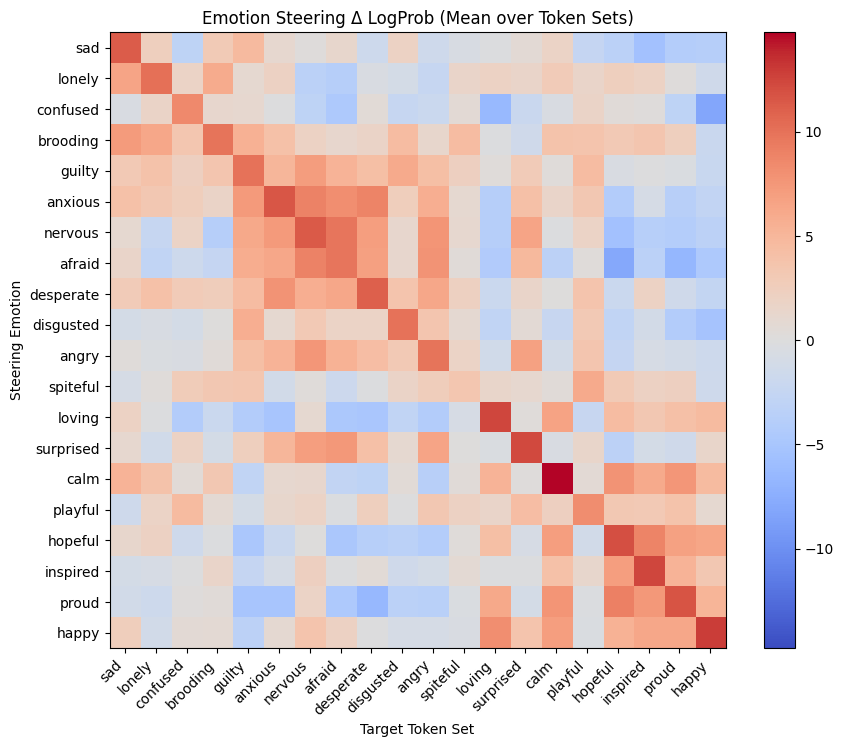

In [ ]:
# [i] abbreviate the modelName for the plot filename
modelName = ""
if kModelIdx == "openai-community/gpt2-medium":
    modelName = "GPT2Medium"
elif kModelIdx == "google/gemma-4-E2B":
    modelName = "Gemma4E2B"

steeringValue = 0.5  # match Anthropic-style

heatmap, emotions = computeEmotionHeatmap(
    allLogProbData,
    emotionTokenSets,
    steeringValue
)

fig = plotEmotionHeatmap(heatmap, emotions)

saveMatplotlibStatic(fig, fileName=f"DeltaLogProbHeatmap{modelName}-{numberEmotions}emotions-layer{gTargetLayer}.png")

In [ ]:
# [6] Generate the 4-quadrant manifold with Valence/Arousal rotation logic
fig = visualizePCAManifold()

# [i] abbreviate the modelName for the plot filename
modelName = ""
if kModelIdx == "openai-community/gpt2-medium":
    modelName = "GPT2Medium"
elif kModelIdx == "google/gemma-4-E2B":
    modelName = "Gemma4E2B"

# [ii] calculate the current number of emotions used
numberEmotions = len(emotionLabels)

# [iii] generate the plot image with the desired name
savePlotlyStatic(fig, fileName=f"PCA{modelName}-{numberEmotions}emotions-layer{gTargetLayer}.png",
    width=800,
    height=800
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[DISK] Static publication-grade image saved to ./research_data/PCAGPT2Medium-20emotions-layer16.png


In [ ]:
# ... and the cosine heatmap
fig = plotCosineSimilarityHeatmapPlotlyAnnotated()

# [i] abbreviate the modelName for the plot filename
modelName = ""
if kModelIdx == "openai-community/gpt2-medium":
    modelName = "GPT2Medium"
elif kModelIdx == "google/gemma-4-E2B":
    modelName = "Gemma4E2B"

# [ii] calculate the current number of emotions used
numberEmotions = len(emotionLabels)

# [iii] generate the plot image with the desired name
savePlotlyStatic(fig, fileName=f"CosineHeatmap{modelName}-{numberEmotions}emotions-layer{gTargetLayer}.png",
    width=1200,
    height=800
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[DISK] Static publication-grade image saved to ./research_data/CosineHeatmapGPT2Medium-20emotions-layer16.png


In [ ]:
# [7] Save vectors and the graph into disk
downloadAllVectorsToPC()